In [2]:
import pandas as pd

In [3]:
purchase_behaviour = pd.read_csv('QVI_purchase_behaviour.csv')
transaction_data = pd.read_excel('QVI_transaction_data.xlsx')

## Preview of Data

In [4]:
purchase_behaviour.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
purchase_behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [6]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [7]:
transaction_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


## Data Cleaning of Purchasing and Transaction Behaviour

In [8]:
purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [9]:
purchase_behaviour.duplicated().sum()   

np.int64(0)

In [10]:
purchase_behaviour.dtypes

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

In [11]:
purchase_behaviour.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [12]:
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [13]:
transaction_data.duplicated().sum()  

np.int64(1)

In [14]:
# Remove duplicate rows
transaction_data = transaction_data.drop_duplicates()

In [15]:
transaction_data.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [16]:
transaction_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835.000000,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,43464.036600,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
std,105.389336,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231
min,43282.000000,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,43646.000000,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


## Outilers Detection on Transaction Data

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


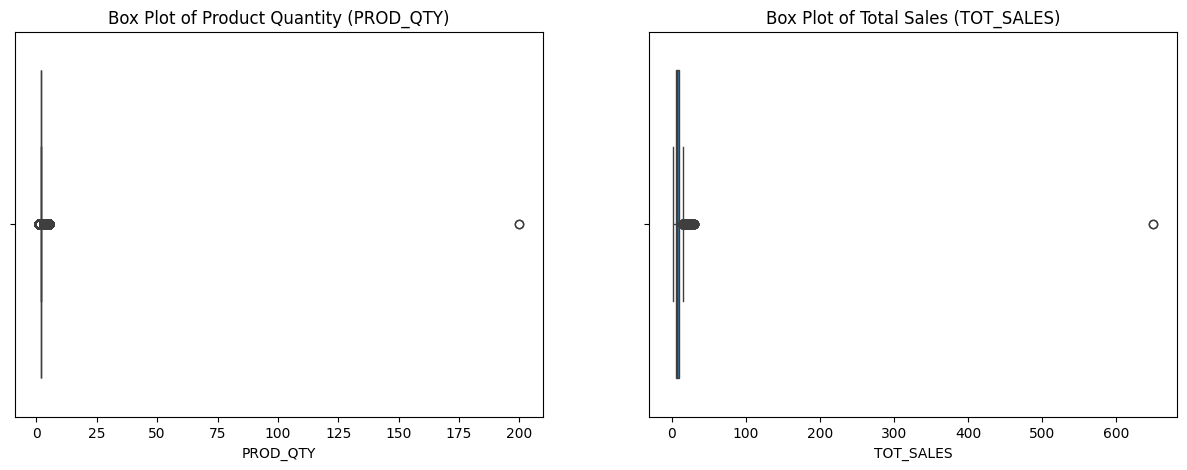

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    ax = axes[0],
    x = transaction_data['PROD_QTY']
)
axes[0].set_title('Box Plot of Product Quantity (PROD_QTY)')

sns.boxplot(
    ax = axes[1],
    x = transaction_data['TOT_SALES']
)
axes[1].set_title('Box Plot of Total Sales (TOT_SALES)')

plt.show()

### Examining the outliers the Transaction Data of Prod Quality

In [19]:
# Look specifically at the extreme outlier
extreme_outlier = transaction_data[transaction_data['PROD_QTY'] == 200]
extreme_outlier



,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [20]:
# Check if this customer (LYLTY_CARD_NBR) has made other transactions
outlier_customer = extreme_outlier['LYLTY_CARD_NBR'].iloc[0]
transaction_data[transaction_data['LYLTY_CARD_NBR'] == outlier_customer]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [21]:
# Remove the commercial customer by their loyalty card number
transaction_data = transaction_data[transaction_data['LYLTY_CARD_NBR'] != outlier_customer]

### Examining the Outliers on for TOT_Sales

In [22]:
# Calculate IQR for 'TOT_SALE'
Q1 = transaction_data['TOT_SALES'].quantile(0.25)
Q3 = transaction_data['TOT_SALES'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find and display outliers
outliers = transaction_data[(transaction_data['TOT_SALES'] < lower_bound) | (transaction_data['TOT_SALES'] > upper_bound)]

print(f"Number of outliers based on TOT_SALES: {len(outliers)}")
print("A few examples of outliers:")
outliers.head(10)

Number of outliers based on TOT_SALES: 576
A few examples of outliers:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
11,43332,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0
56,43601,74,74336,73182,84,GrnWves Plus Btroot & Chilli Jam 180g,5,15.5
72,43331,96,96203,96025,7,Smiths Crinkle Original 330g,5,28.5
100,43605,130,130108,134125,2,Cobs Popd Sour Crm &Chives Chips 110g,5,19.0
102,43600,133,133250,137666,30,Doritos Corn Chips Cheese Supreme 170g,4,17.6
124,43602,168,168219,170719,33,Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,4,15.2
165,43602,222,222209,222693,40,Thins Chips Seasonedchicken 175g,5,16.5
191,43329,257,257258,257308,114,Kettle Sensations Siracha Lime 150g,4,18.4
193,43331,262,262126,262025,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,4,18.4


In [23]:
# Convert Excel integer date to datetime
# The origin for Excel is Dec 30, 1899
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], unit='D', origin='1899-12-30')

In [24]:
# How many unique product names are there?
transaction_data['PROD_NAME'].nunique()

114

In [25]:
# Show all unique product names in sorted order
sorted(transaction_data['PROD_NAME'].dropna().unique())


['Burger Rings 220g',
 'CCs Nacho Cheese    175g',
 'CCs Original 175g',
 'CCs Tasty Cheese    175g',
 'Cheetos Chs & Bacon Balls 190g',
 'Cheetos Puffs 165g',
 'Cheezels Cheese 330g',
 'Cheezels Cheese Box 125g',
 'Cobs Popd Sea Salt  Chips 110g',
 'Cobs Popd Sour Crm  &Chives Chips 110g',
 'Cobs Popd Swt/Chlli &Sr/Cream Chips 110g',
 'Dorito Corn Chp     Supreme 380g',
 'Doritos Cheese      Supreme 330g',
 'Doritos Corn Chip Mexican Jalapeno 150g',
 'Doritos Corn Chip Southern Chicken 150g',
 'Doritos Corn Chips  Cheese Supreme 170g',
 'Doritos Corn Chips  Nacho Cheese 170g',
 'Doritos Corn Chips  Original 170g',
 'Doritos Mexicana    170g',
 'Doritos Salsa       Medium 300g',
 'Doritos Salsa Mild  300g',
 'French Fries Potato Chips 175g',
 'Grain Waves         Sweet Chilli 210g',
 'Grain Waves Sour    Cream&Chives 210G',
 'GrnWves Plus Btroot & Chilli Jam 180g',
 'Infuzions BBQ Rib   Prawn Crackers 110g',
 'Infuzions Mango     Chutny Papadums 70g',
 'Infuzions SourCream&Herbs Veg St

In [26]:
import re
import pandas as pd

def clean_prod_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    name = re.sub(r'\s+', ' ', name)   # collapse multiple spaces into one
    return name

transaction_data['PROD_NAME_CLEAN'] = transaction_data['PROD_NAME'].apply(clean_prod_name)

# See what changed
transaction_data[['PROD_NAME', 'PROD_NAME_CLEAN']].drop_duplicates().head(20)

,PROD_NAME,PROD_NAME_CLEAN
0,Natural Chip Compny SeaSalt175g,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle Tortilla ChpsHny&Jlpno Chili 150g
5,Old El Paso Salsa Dip Tomato Mild 300g,Old El Paso Salsa Dip Tomato Mild 300g
6,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths Crinkle Chips Salt & Vinegar 330g
7,Grain Waves Sweet Chilli 210g,Grain Waves Sweet Chilli 210g
8,Doritos Corn Chip Mexican Jalapeno 150g,Doritos Corn Chip Mexican Jalapeno 150g
9,Grain Waves Sour Cream&Chives 210G,Grain Waves Sour Cream&Chives 210G


In [27]:
changed_names = transaction_data[transaction_data['PROD_NAME'] != transaction_data['PROD_NAME_CLEAN']]
changed_names[['PROD_NAME', 'PROD_NAME_CLEAN']].drop_duplicates()

,PROD_NAME,PROD_NAME_CLEAN
0,Natural Chip Compny SeaSalt175g,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths Chip Thinly S/Cream&Onion 175g
5,Old El Paso Salsa Dip Tomato Mild 300g,Old El Paso Salsa Dip Tomato Mild 300g
...,...,...
487,Natural ChipCo Sea Salt & Vinegr 175g,Natural ChipCo Sea Salt & Vinegr 175g
521,RRD SR Slow Rst Pork Belly 150g,RRD SR Slow Rst Pork Belly 150g
528,RRD Pc Sea Salt 165g,RRD Pc Sea Salt 165g
549,Smith Crinkle Cut Bolognese 150g,Smith Crinkle Cut Bolognese 150g


## Merge Data

In [28]:
merged_data = pd.merge(transaction_data, purchase_behaviour, on='LYLTY_CARD_NBR', how='left')

merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_CLEAN,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural Chip Compny SeaSalt175g,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs Nacho Cheese 175g,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths Crinkle Cut Chips Chicken 170g,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths Chip Thinly S/Cream&Onion 175g,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle Tortilla ChpsHny&Jlpno Chili 150g,MIDAGE SINGLES/COUPLES,Budget


In [29]:
print(merged_data.isnull().sum())

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PROD_NAME_CLEAN     0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [30]:
# Drop the original PROD_NAME column to avoid confusion
merged_data = merged_data.drop(columns=['PROD_NAME'])

# Display the first few rows to confirm the column is gone
merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PROD_NAME_CLEAN,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,2,6.0,Natural Chip Compny SeaSalt175g,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,3,6.3,CCs Nacho Cheese 175g,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,2,2.9,Smiths Crinkle Cut Chips Chicken 170g,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,5,15.0,Smiths Chip Thinly S/Cream&Onion 175g,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,3,13.8,Kettle Tortilla ChpsHny&Jlpno Chili 150g,MIDAGE SINGLES/COUPLES,Budget


In [31]:
transaction_data['PROD_NAME_CLEAN'].unique()

merged_data = merged_data[~merged_data['PROD_NAME_CLEAN'].str.contains("salsa", case=False)]


In [32]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246739 entries, 0 to 264832
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246739 non-null  datetime64[ns]
 1   STORE_NBR         246739 non-null  int64         
 2   LYLTY_CARD_NBR    246739 non-null  int64         
 3   TXN_ID            246739 non-null  int64         
 4   PROD_NBR          246739 non-null  int64         
 5   PROD_QTY          246739 non-null  int64         
 6   TOT_SALES         246739 non-null  float64       
 7   PROD_NAME_CLEAN   246739 non-null  object        
 8   LIFESTAGE         246739 non-null  object        
 9   PREMIUM_CUSTOMER  246739 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 20.7+ MB


## Feature Engineering

In [33]:
# Extract pack size from PROD_NAME
# We can use a regular expression to find numbers followed by 'g'
merged_data['PACK_SIZE'] = merged_data['PROD_NAME_CLEAN'].str.extract(r'(\d+)').astype(float)

# Let's check the results
print(merged_data[['PROD_NAME_CLEAN', 'PACK_SIZE']].head())
print("\nSummary of PACK_SIZE:")
print(merged_data['PACK_SIZE'].describe())


                            PROD_NAME_CLEAN  PACK_SIZE
0           Natural Chip Compny SeaSalt175g      175.0
1                     CCs Nacho Cheese 175g      175.0
2     Smiths Crinkle Cut Chips Chicken 170g      170.0
3     Smiths Chip Thinly S/Cream&Onion 175g      175.0
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g      150.0

Summary of PACK_SIZE:
count    246739.000000
mean        175.583523
std          59.432239
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64


In [34]:
# Extract brand name from PROD_NAME
merged_data['BRAND'] = merged_data['PROD_NAME_CLEAN'].str.split().str[0]

# Let's check the unique brand names found
print("\nUnique brand names found:")
print(merged_data['BRAND'].unique())

# And a summary of the brands
print("\nBrand counts:")
print(merged_data['BRAND'].value_counts())




Unique brand names found:
['Natural' 'CCs' 'Smiths' 'Kettle' 'Grain' 'Doritos' 'Twisties' 'WW'
 'Thins' 'Burger' 'NCC' 'Cheezels' 'Infzns' 'Red' 'Pringles' 'Dorito'
 'Infuzions' 'Smith' 'GrnWves' 'Tyrrells' 'Cobs' 'French' 'RRD' 'Tostitos'
 'Cheetos' 'Woolworths' 'Snbts' 'Sunbites']

Brand counts:
BRAND
Kettle        41288
Smiths        27389
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64


In [35]:
# High-level summary metrics
total_sales = merged_data['TOT_SALES'].sum()
total_customers = merged_data['LYLTY_CARD_NBR'].nunique()
total_transactions = merged_data['TXN_ID'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Transactions: {total_transactions:,}")

Total Sales: $1,805,171.70
Total Customers: 71,287
Total Transactions: 245,255


## Final Insights 

In [36]:
# Ensure numeric and remove NaNs in the key metric
merged_data['TOT_SALES'] = pd.to_numeric(merged_data['TOT_SALES'], errors='coerce')
df = merged_data.dropna(subset=['TOT_SALES', 'LYLTY_CARD_NBR'])

def build_segment_summary(df, group_cols):
    grp = df.groupby(group_cols).agg(
        total_sales = ('TOT_SALES', 'sum'),
        total_transactions = ('TXN_ID', 'nunique'),
        avg_sales_per_txn = ('TOT_SALES', 'mean'),
        total_customers = ('LYLTY_CARD_NBR', 'nunique')
    ).reset_index()
    grp['sales_per_customer'] = grp['total_sales'] / grp['total_customers']
    grp = grp.sort_values('total_sales', ascending=False).reset_index(drop=True)
    grp['rank_by_sales'] = grp['total_sales'].rank(method='dense', ascending=False).astype(int)
    return grp

# Examples: change group_cols as needed
summary_by_lifestage = build_segment_summary(df, ['LIFESTAGE'])
summary_by_premium = build_segment_summary(df, ['PREMIUM_CUSTOMER'])
summary_by_lifestage_premium = build_segment_summary(df, ['LIFESTAGE', 'PREMIUM_CUSTOMER'])

# Show top segments
print("Top Lifestage segments by sales")
display(summary_by_lifestage.head(10))

print("Top Premium segments by sales")
display(summary_by_premium.head(10))

print("Top Lifestage x Premium segments by sales")
display(summary_by_lifestage_premium.head(20))

Top Lifestage segments by sales


,LIFESTAGE,total_sales,total_transactions,avg_sales_per_txn,total_customers,sales_per_customer,rank_by_sales
0,OLDER SINGLES/COUPLES,376013.65,50506,7.403009,14389,26.132021,1
1,RETIREES,342381.90,46205,7.373994,14555,23.523318,2
2,OLDER FAMILIES,328519.90,44755,7.274899,9630,34.114216,3
3,YOUNG FAMILIES,294627.90,40190,7.275841,9036,32.606009,4
4,YOUNG SINGLES/COUPLES,243756.60,33863,7.175854,14044,17.356636,5
5,MIDAGE SINGLES/COUPLES,172523.80,23259,7.373442,7141,24.159613,6
6,NEW FAMILIES,47347.95,6477,7.287664,2492,18.999980,7


Top Premium segments by sales


,PREMIUM_CUSTOMER,total_sales,total_transactions,avg_sales_per_txn,total_customers,sales_per_customer,rank_by_sales
0,Mainstream,700865.40,94524,7.374193,28734,24.391501,1
1,Budget,631406.85,86197,7.277458,24006,26.302043,2
2,Premium,472899.45,64536,7.282771,18547,25.497355,3


Top Lifestage x Premium segments by sales


,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,total_transactions,avg_sales_per_txn,total_customers,sales_per_customer,rank_by_sales
0,OLDER FAMILIES,Budget,156863.75,21322,7.291241,4611,34.019464,1
1,YOUNG SINGLES/COUPLES,Mainstream,147582.20,19482,7.551279,7917,18.641177,2
2,RETIREES,Mainstream,145168.95,19878,7.269352,6358,22.832487,3
3,YOUNG FAMILIES,Budget,129717.95,17629,7.302705,3953,32.815065,4
4,OLDER SINGLES/COUPLES,Budget,127833.60,17078,7.444305,4849,26.362879,5
5,OLDER SINGLES/COUPLES,Mainstream,124648.50,16958,7.306049,4858,25.658399,6
6,OLDER SINGLES/COUPLES,Premium,123531.55,16472,7.460085,4682,26.384355,7
7,RETIREES,Budget,105916.30,14147,7.445786,4385,24.154230,8
8,OLDER FAMILIES,Mainstream,96413.55,13131,7.281440,2788,34.581618,9
9,RETIREES,Premium,91296.65,12180,7.461315,3812,23.949803,10


## Data Visualizations

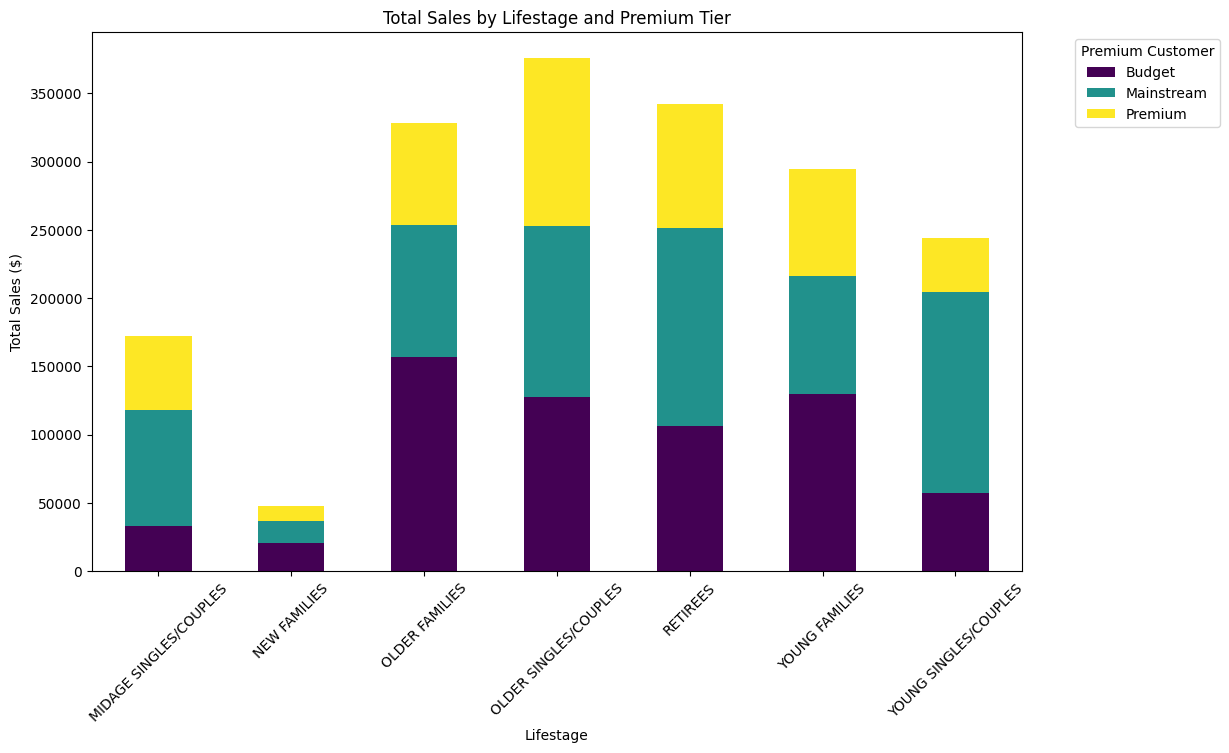

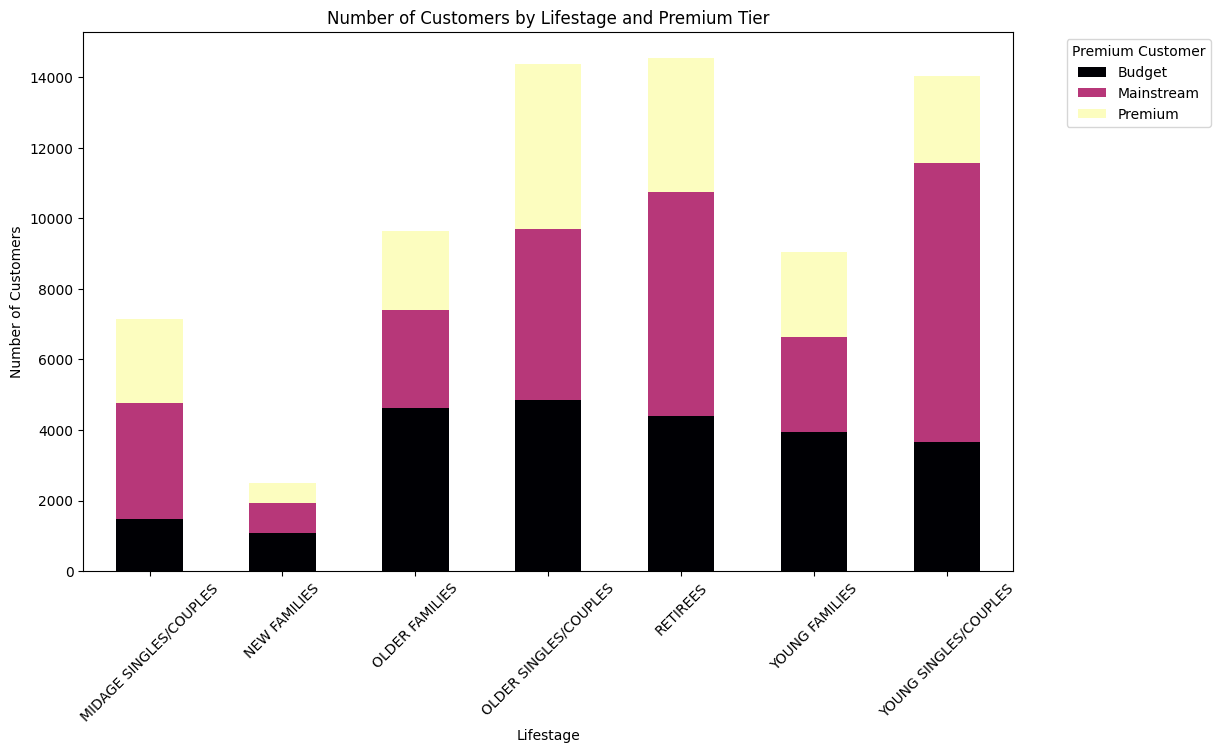

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize Total Sales by Segment
sales_plot = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()

sales_plot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Total Sales by Lifestage and Premium Tier')
plt.ylabel('Total Sales ($)')
plt.xlabel('Lifestage')
plt.legend(title='Premium Customer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

# 2. Visualize Customer Counts by Segment
cust_plot = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().unstack()

cust_plot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='magma')
plt.title('Number of Customers by Lifestage and Premium Tier')
plt.ylabel('Number of Customers')
plt.xlabel('Lifestage')
plt.legend(title='Premium Customer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

Average Pack Size (grams) by Segment:
PREMIUM_CUSTOMER            Budget  Mainstream     Premium
LIFESTAGE                                                 
MIDAGE SINGLES/COUPLES  174.182690  177.898693  174.585391
NEW FAMILIES            174.766643  175.629748  175.245296
OLDER FAMILIES          175.546342  175.175666  174.524752
OLDER SINGLES/COUPLES   175.334673  174.812145  176.485657
RETIREES                176.395641  175.213671  176.368421
YOUNG FAMILIES          175.459720  174.202059  174.659032
YOUNG SINGLES/COUPLES   173.378981  178.344249  174.002563


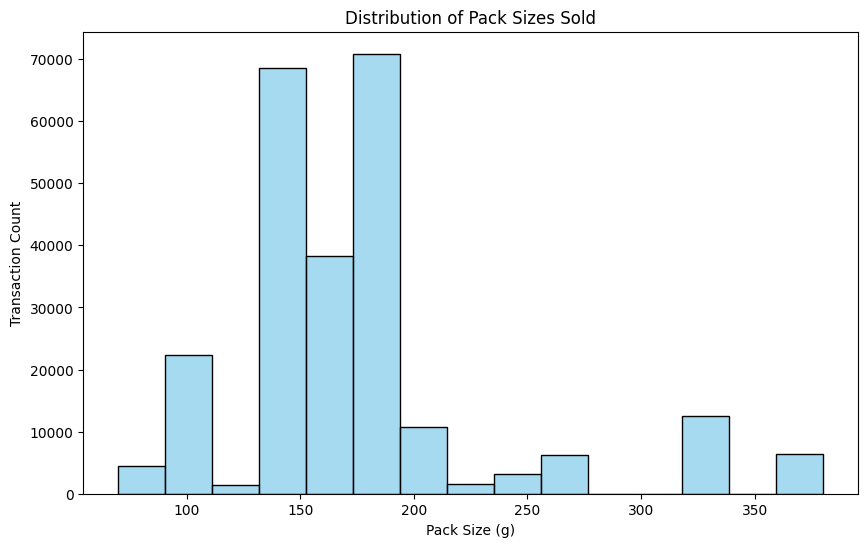

In [39]:
# Calculate the average pack size bought by each segment
pack_size_analysis = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PACK_SIZE'].mean().unstack()

print("Average Pack Size (grams) by Segment:")
print(pack_size_analysis)

# Visualize Pack Size Distribution for the whole category
plt.figure(figsize=(10, 6))
sns.histplot(merged_data['PACK_SIZE'], bins=15, kde=False, color='skyblue')
plt.title('Distribution of Pack Sizes Sold')
plt.xlabel('Pack Size (g)')
plt.ylabel('Transaction Count')
plt.show()

In [40]:
# Function to get top brands for a specific segment
def get_top_brands(lifestage, premium_tier):
    segment_data = merged_data[(merged_data['LIFESTAGE'] == lifestage) & 
                               (merged_data['PREMIUM_CUSTOMER'] == premium_tier)]
    return segment_data['BRAND'].value_counts().head(3)

print("Top Brands for Mainstream Young Singles/Couples:")
print(get_top_brands('YOUNG SINGLES/COUPLES', 'Mainstream'))

print("\nTop Brands for Budget Older Families:")
print(get_top_brands('OLDER FAMILIES', 'Budget'))

Top Brands for Mainstream Young Singles/Couples:
BRAND
Kettle      3844
Pringles    2315
Doritos     2076
Name: count, dtype: int64

Top Brands for Budget Older Families:
BRAND
Kettle      3320
Smiths      2640
Pringles    1996
Name: count, dtype: int64


In [41]:
# Calculate Price per Unit
merged_data['PRICE_PER_UNIT'] = merged_data['TOT_SALES'] / merged_data['PROD_QTY']

# Compare the average price per unit for Mainstream vs others in Young Singles
avg_price = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().unstack()

print("Average Price per Unit by Segment:")
print(avg_price)

Average Price per Unit by Segment:
PREMIUM_CUSTOMER          Budget  Mainstream   Premium
LIFESTAGE                                             
MIDAGE SINGLES/COUPLES  3.743328    3.994241  3.770698
NEW FAMILIES            3.917688    3.916133  3.872110
OLDER FAMILIES          3.745340    3.737077  3.717000
OLDER SINGLES/COUPLES   3.882096    3.814665  3.893236
RETIREES                3.924404    3.844294  3.920942
YOUNG FAMILIES          3.760737    3.724533  3.762150
YOUNG SINGLES/COUPLES   3.657366    4.065642  3.665414
